In [ ]:
# gndirt
# Description: Infrared Thermometer: Ground surface temperature
# Site: Houston, TX; Tracking Aerosol Convection interactions ExpeRiment (HOU)
# Location: Houston, TX; AMF1 (main site for TRACER) 
# Facility Code: M1
# Category: Radiometric
# Data Type: Routine Data 
# Source Instrument/Data: Infrared Thermometer 
# Start Date: 2021-08-04 
# End Date: 2022-10-01 

In [26]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs;import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

In [27]:
data_location='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Figures/campaign_data/surface_data/'
data=xr.open_dataset(data_location+'/04-10st_houston.nc')

land minmax(297.59889526367186, 312.4776306152344)
ocean minmax(301.74322306315105, 302.3276743570963)


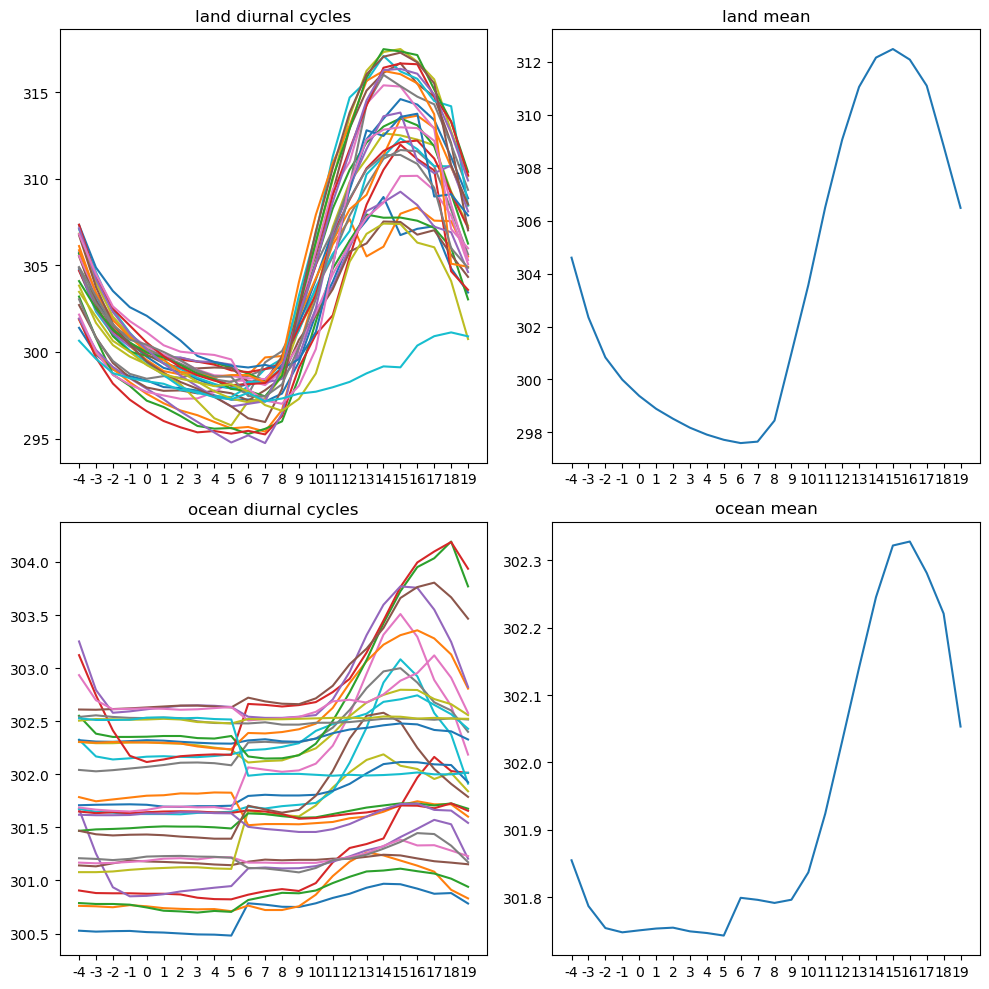

In [28]:
#full diurnal cycles for june
lat1=np.where(data['LAT401_521']==29.5)[0][0];lon1=np.where(data['LONN439_N319']==-95.5)[0][0]
lat2=np.where(data['LAT401_521']==27.5)[0][0];lon2=np.where(data['LONN439_N319']==-94.5)[0][0]
times=data['TIME'].values.astype(str)
date=[t for t in times if t.startswith('2022-06')]
where=np.where(np.isin(times,date)*1)[0]
junediurnal_land=data['SKT'].isel(TIME=where,LEV=0,LAT401_521=lat1,LONN439_N319=lon1)
junediurnal_ocean=data['SKT'].isel(TIME=where,LEV=0,LAT401_521=lat2,LONN439_N319=lon2)

#split up diurnal cycles 
num_jobs=30 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
num_parcels=len(junediurnal_land['TIME']) #total number of times
job_range = num_parcels//num_jobs #number of parcels per job 

mean_land=np.zeros((23+1));mean_ocean=np.zeros((23+1))
channel_aspect_ratio = 1
size=10
plt.figure(figsize=(size, size/channel_aspect_ratio)) 
plt.subplot(2,2,1)
plt.title('land diurnal cycles')
for job_id in range(1,31):
    start_job = (job_id - 1) * job_range
    end_job = start_job + job_range
    singlediurnal=junediurnal_land.isel(TIME=slice(start_job,end_job))
    mean_land+=singlediurnal.values
    plt.plot(singlediurnal)
    plt.xticks(ticks=np.arange(0,24,1),labels=np.arange(1-5,24-5+1,1))

plt.subplot(2,2,2)
plt.plot(mean_land/30)
plt.title('land mean')
plt.xticks(ticks=np.arange(0,24,1),labels=np.arange(1-5,24-5+1,1))
    
plt.subplot(2,2,3)
plt.title('ocean diurnal cycles')
for job_id in range(1,31):
    start_job = (job_id - 1) * job_range
    end_job = start_job + job_range
    singlediurnal=junediurnal_ocean.isel(TIME=slice(start_job,end_job))
    mean_ocean+=singlediurnal.values
    plt.plot(singlediurnal)
    plt.xticks(ticks=np.arange(0,24,1),labels=np.arange(1-5,24-5+1,1))


plt.subplot(2,2,4)
plt.plot(mean_ocean/30)
plt.title('ocean mean')
plt.xticks(ticks=np.arange(0,24,1),labels=np.arange(1-5,24-5+1,1))

plt.tight_layout()

print(f'land minmax{mean_land.min()/30,mean_land.max()/30}')
print(f'ocean minmax{mean_ocean.min()/30,mean_ocean.max()/30}')

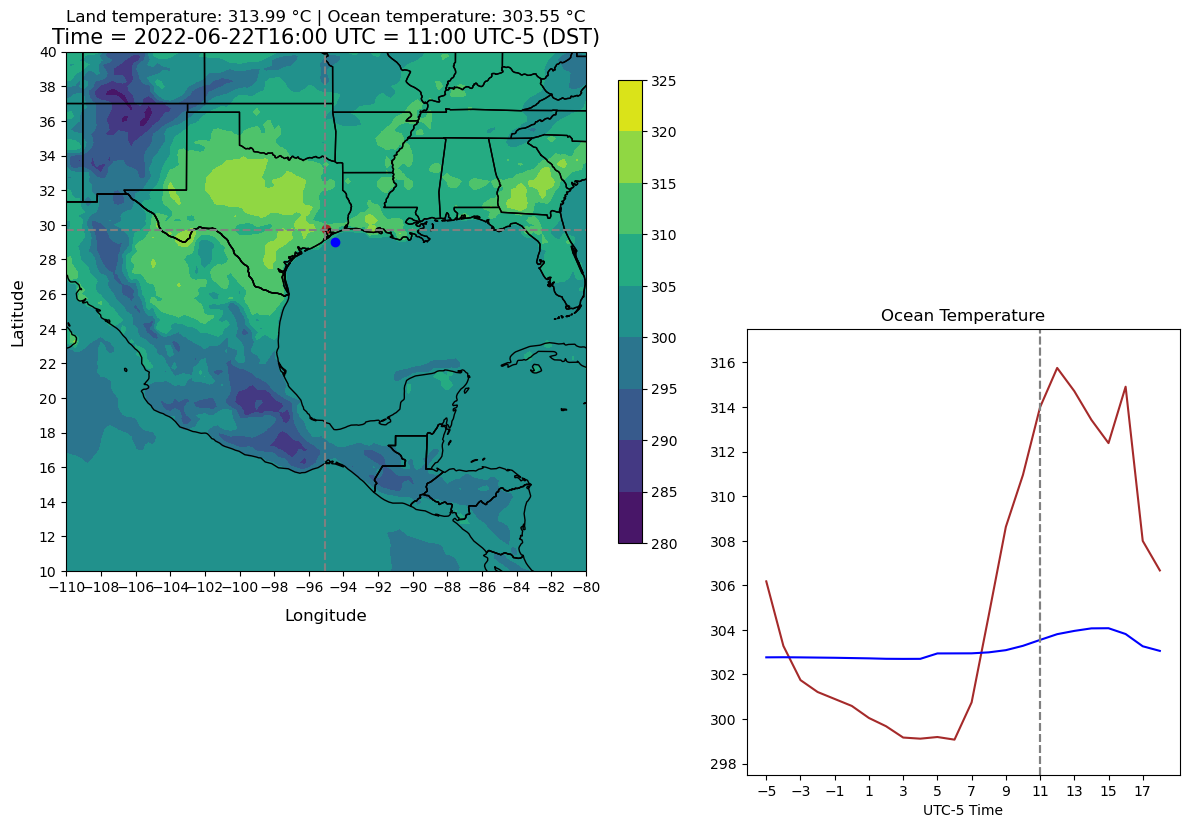

In [29]:
#Lon Lat Values
lon=-95.059;lat=29.67

# Extract time values
times = data['TIME'].values.astype(str)
date = [t for t in times if t.startswith('2022-06-22T16')]  # Select specific time

# Get index of selected time
begin = np.where(times == date[0])
st = data['SKT'].isel(LEV=0, TIME=begin[0][0])

# Create figure and GridSpec layout
fig = plt.figure(figsize=(12, 10), dpi=100)
gs = GridSpec(nrows=2, ncols=2, figure=fig, height_ratios=[1, 1], width_ratios=[3, 2])

# Select land and ocean locations
land_lat=29.75;ocean_lat=29
land_lon=-95;ocean_lon=-94.5
lat1 = np.where(data['LAT401_521'] == land_lat)[0][0]
lon1 = np.where(data['LONN439_N319'] == ocean_lon)[0][0]
lat2 = np.where(data['LAT401_521'] == ocean_lat)[0][0]
lon2 = np.where(data['LONN439_N319'] == ocean_lon)[0][0]

# Main map plot
ax1 = fig.add_subplot(gs[:, 0], projection=ccrs.PlateCarree())
contour = ax1.contourf(data['LONN439_N319'], data['LAT401_521'], st, transform=ccrs.PlateCarree())
plt.colorbar(contour, ax=ax1, shrink=0.5)
ax1.scatter(land_lon, land_lat, color='brown')  # Land point
ax1.scatter(ocean_lon, ocean_lat, color='blue')  # Ocean point

# Add geographical features
ax1.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')
ax1.add_feature(cfeature.STATES, linestyle='-', edgecolor='black')
ax1.add_feature(cfeature.NaturalEarthFeature(
    category='cultural', name='admin_0_countries', scale='50m', edgecolor='black', facecolor='none'))

# Set axis labels and title
ax1.set_xticks(data['LONN439_N319'][::8])
ax1.set_yticks(data['LAT401_521'][::8])
ax1.set_xlabel('Longitude', fontsize=12, labelpad=10)
ax1.set_ylabel('Latitude', fontsize=12, labelpad=10)
ax1.set_title(f'Time = {date[0][:13]}:00 UTC = 11:00 UTC-5 (DST)', fontsize=15)



date_all = [t for t in times if t.startswith('2022-06-22')]
where = np.where(np.isin(times, date_all) * 1)[0]
landtemp = data['SKT'].isel(TIME=where, LEV=0, LAT401_521=lat1, LONN439_N319=lon1)
oceantemp = data['SKT'].isel(TIME=where, LEV=0, LAT401_521=lat2, LONN439_N319=lon2)

#Time Ints for Plotting
import pandas as pd
time_values = pd.to_datetime(data['TIME'].isel(TIME=where).values)
utc_times = time_values.strftime('%H')
UTC5_times=utc_times.to_numpy().astype(int)-5

# Get specific values
landtemp_val = st.isel(LAT401_521=lat1, LONN439_N319=lon1).values
oceantemp_val = st.isel(LAT401_521=lat2, LONN439_N319=lon2).values
# print(f'Land temperature: {landtemp_val:.2f}')
# print(f'Ocean temperature: {oceantemp_val:.2f}')
ax1.text(0.5, 1.05, f'Land temperature: {landtemp_val:.2f} °C | Ocean temperature: {oceantemp_val:.2f} °C',  
         ha='center', va='bottom', fontsize=12, transform=ax1.transAxes)

# Land temperature time series plot
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(UTC5_times,landtemp, color='brown')
ax2.set_xticks(UTC5_times[::2]);ax2.set_xlabel('UTC-5 Time')
ax2.set_yticks(ax2.get_yticks()[::2])
ax2.set_title('Land Temperature')

# Ocean temperature time series plot
ax2.plot(UTC5_times, oceantemp, color='blue')
ax2.set_xticks(UTC5_times[::2]);ax3.set_xlabel('UTC-5 Time')
ax2.set_yticks(ax2.get_yticks()[::2])
ax2.set_title('Ocean Temperature')

#Adding Line Markers

ax1.axvline(lon,linestyle='dashed',color='grey')
ax1.axhline(lat,linestyle='dashed',color='grey')
ax2.axvline(11,linestyle='dashed',color='grey')
ax2.axvline(11,linestyle='dashed',color='grey')

import matplotlib.ticker as ticker
ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=12))

#Fixing layout
plt.tight_layout()



In [10]:
# #files with skin_temp variable
# indices=[19,43,46,79,282,293,297,351]
# [nc_filenames[i] for i in indices]

In [8]:
# #find single day skin temperature value 
# which_file=46
# data_location='/mnt/lustre/koa/koastore/torri_group/air/surface_data'
# data=xr.open_dataset(data_location+'/'+nc_filenames[int(which_file)-1])
# var_list= [x for x in data]
# select_var=data[var_list[int(var_list.index('skin_temp'))]] #index 3
# select_var.plot()
# print(np.mean(select_var).values)

In [ ]:
# #loop to average ALL skin temperature value 
# which_file=19
# data_location='/mnt/lustre/koa/koastore/torri_group/air/surface_data'
# data=xr.open_dataset(data_location+'/'+nc_filenames[int(which_file)-1])
# var_list= [x for x in data]
# select_var=data[var_list[int(var_list.index('skin_temp'))]] #index 3
# average=select_var

# for k in range(20, len(nc_filenames)):
#     if k in  [i for i, filename in enumerate(nc_filenames) if filename.startswith('houecmwfsfce')]: #ignores this file type
#         print(f'skipping cmwfsfce dataset at index {k}')
#     else:
#         which_file=k
#         data_location='/mnt/lustre/koa/koastore/torri_group/air/surface_data'
#         data=xr.open_dataset(data_location+'/'+nc_filenames[int(which_file)-1])
#         var_list= [x for x in data]
#         if 'sfc_ir_temp' in var_list: 
#             print(f'skipping dataset with sfc_ir_temp variable at index {k}')
#         else:
#             select_var=data[var_list[int(var_list.index('skin_temp'))]] #index 3
#             average=xr.concat([average, select_var], dim='new_dim').mean(dim='new_dim') #average of 8 file data
# average.plot()
# print(np.mean(average).values)